### Dataset sobre a Vacinação da Covid-19 na Microrregião de Anápolis, entre 2021 e 2023

Carregando o dataset:

In [13]:
import pandas as pd

df = pd.read_csv("../data/raw/vacinacovidgoias.csv", encoding="utf-8")

In [2]:
df.head()

,Município de vacinação,Idade Evento,Data da Notificação,Raça/Cor,Sexo,Imunobiológico (vacina),Dose,Gestante,Mês de gestação,Mulher amamentando no momento da vacinação?,Tipo de Evento,Reação / evento adverso,Classificação de gravidade,Gravidade,Desfecho (evolução do caso),Doenças (CID10) - Preexistente,Medicamento em uso anterior ou durante a vacinação,Nome do Medicamento,Houve atendimento médico?,Tipo de Atendimento
0,Abadiânia,18.0,2/16/2022,Branca,Masculino,1: Astrazeneca/Fiocruz,1: 1ª Dose,Não,0.0,Não,1: Erro de Imunização,1: Dose inadequada,1: Não grave,0,1: Cura sem sequelas,0,Não,Não,Não,0
1,Abadiânia,18.0,2/16/2022,Parda,Masculino,1: Astrazeneca/Fiocruz,1: 1ª Dose / 2: 2ª Dose / 3: 3ª dose,Não,0.0,Não,1: Erro de Imunização,1: Dose inadequada,1: Não grave,0,1: Cura sem sequelas,0,Não,Não,Não,0
2,Abadiânia,18.0,2/16/2022,Parda,Feminino,1: Astrazeneca/Fiocruz,1: 1ª Dose / 2: - 2ª Dose,Não,0.0,Não,1: Erro de Imunização,1: Dose inadequada,1: Não grave,0,1: Cura sem sequelas,0,Não,Não,Não,0
3,Abadiânia,18.0,2/16/2022,Branca,Feminino,1: Astrazeneca/Fiocruz,1: 1ª Dose / 2: 2ª Dose,Não,0.0,Não,1: Erro de Imunização,1: Dose inadequada,1: Não grave,0,1: Cura sem sequelas,0,Não,Não,Não,0
4,Abadiânia,18.0,2/16/2022,Branca,Feminino,1: Astrazeneca/Fiocruz,1: 1ª Dose,Não,0.0,Não,1: Erro de Imunização,1: Dose inadequada,1: Não grave,0,1: Cura sem sequelas,0,Não,Não,Não,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 20 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Município de vacinação                              444 non-null    object 
 1   Idade Evento                                        444 non-null    float64
 2   Data da Notificação                                 444 non-null    object 
 3   Raça/Cor                                            444 non-null    object 
 4   Sexo                                                444 non-null    object 
 5   Imunobiológico (vacina)                             444 non-null    object 
 6   Dose                                                443 non-null    object 
 7   Gestante                                            444 non-null    object 
 8   Mês de gestação                                     444 non-null    float64
 9  

#### Limpando o dataset

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 452 entries, 0 to 451
Data columns (total 20 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   municipio_de_vacinacao                              444 non-null    object 
 1   idade_evento                                        444 non-null    float64
 2   data_da_notificacao                                 444 non-null    object 
 3   racacor                                             444 non-null    object 
 4   sexo                                                444 non-null    object 
 5   imunobiologico_vacina                               444 non-null    object 
 6   dose                                                443 non-null    object 
 7   gestante                                            444 non-null    object 
 8   mes_de_gestacao                                     444 non-null    float64
 9  

Convertendo datas, facilitando a busca por filtração por data

In [18]:
df['data_da_notificacao'] = pd.to_datetime(df['data_da_notificacao'], errors='coerce')

Convertendo idade, facilitando a agrupação e utilização de cálculos, como média

In [19]:
df['idade_evento'] = pd.to_numeric(df['idade_evento'], errors='coerce')

Algumas colunas estão utilizando "id" de maneira irrelevante para a análise, então iremos remover os ids:

In [21]:
# imunobiologico_vacina
df['imunobiologico_vacina'] = df['imunobiologico_vacina']\
    .str.split(":").str[1].str.strip()

In [22]:
# dose
df['dose'] = df['dose'].str.split("/").str[0]\
    .str.split(":").str[1].str.strip()

In [ ]:
# tipo_de_evento
df['tipo_de_evento'] = df['tipo_de_evento']\
    .str.split(":").str[1].str.strip()

In [23]:
# classificacao_de_gravidade
df['classificacao_de_gravidade'] = df['classificacao_de_gravidade']\
    .str.split(":").str[1].str.strip()

In [ ]:
#Verificando se tem valores nulos:
df.isnull().sum()

municipio_de_vacinacao                                  8
idade_evento                                            8
data_da_notificacao                                   226
racacor                                                 8
sexo                                                    8
imunobiologico_vacina                                   8
dose                                                    9
gestante                                                8
mes_de_gestacao                                         8
mulher_amamentando_no_momento_da_vacinacao              8
tipo_de_evento                                          8
reacao__evento_adverso                                 14
classificacao_de_gravidade                              9
gravidade                                               8
desfecho_evolucao_do_caso                               9
doencas_cid10__preexistente                            45
medicamento_em_uso_anterior_ou_durante_a_vacinacao    169
nome_do_medica

In [ ]:
# Removendo duplicados
df = df.drop_duplicates()

In [ ]:
# Resetando o indice, reorganizando os numeros das linhas
df = df.reset_index(drop=True)

Salvando o dataset limpo:

In [ ]:
import pandas as pd

# 1. Carregar os dados
df = pd.read_csv("../data/raw/vacinacovidgoias.csv", encoding="utf-8")

# --- LIMPANDO OS NOMES DAS COLUNAS ---

# Tudo em minúsculo e sem espaços sobrando
df.columns = df.columns.str.lower().str.strip()

# Remover parênteses e interrogação 
df.columns = df.columns.str.replace("(", "").str.replace(")", "").str.replace("?", "", regex=False)

# Trocar espaços e barras por (_)
df.columns = df.columns.str.replace(" ", "_").str.replace("/", "_")

# Passo D: Agora corrigimos os acentos manualmente (mais simples de entender)
# Use o print(df.columns) se tiver dúvida de como o nome está escrito agora
df = df.rename(columns={
    'município_de_vacinação': 'municipio_de_vacinacao',
    'data_da_notificação': 'data_da_notificacao',
    'raça_cor': 'raca_cor',
    'imunobiológico_vacina': 'imunobiologico_vacina',
    'mês_de_gestação': 'mes_de_gestacao',
    'mulher_amamentando_no_momento_da_vacinação': 'mulher_amamentando',
    'reação___evento_adverso': 'reacao_evento_adverso',
    'classificação_de_gravidade': 'classificacao_de_gravidade',
    'desfecho_evolução_do_caso': 'desfecho_evolucao',
    'doenças_cid10_-_preexistente': 'doencas_preexistentes',
    'houve_atendimento_médico': 'houve_atendimento_medico'
})

# --- LIMPANDO O CONTEÚDO DAS LINHAS ---

# Lista das colunas onde queremos tirar o "1: ", "2: "
colunas_para_limpar = [
    'imunobiologico_vacina', 'dose', 'tipo_de_evento', 
    'reacao_evento_adverso', 'classificacao_de_gravidade', 
    'desfecho_evolucao', 'doencas_preexistentes'
]

for col in colunas_para_limpar:
    # Verificamos se a coluna existe antes de limpar (segurança extra)
    if col in df.columns:
        df[col] = df[col].str.replace(r'\d+:\s*', '', regex=True)

# Salvar o resultado
df.to_csv("../data/processed/vacinacovid_limpo.csv", index=False, encoding="utf-8-sig", sep=";")

print("Colunas limpas com sucesso!")
print(df.columns)

Colunas limpas com sucesso!
Index(['municipio_de_vacinacao', 'idade_evento', 'data_da_notificacao',
       'raca_cor', 'sexo', 'imunobiologico_vacina', 'dose', 'gestante',
       'mes_de_gestacao', 'mulher_amamentando', 'tipo_de_evento',
       'reacao_evento_adverso', 'classificacao_de_gravidade', 'gravidade',
       'desfecho_evolucao', 'doencas_preexistentes',
       'medicamento_em_uso_anterior_ou_durante_a_vacinação',
       'nome_do_medicamento', 'houve_atendimento_medico',
       'tipo_de_atendimento'],
      dtype='object')


### Atividade 3:

In [3]:
df.describe()

,idade_evento,mes_de_gestacao
count,444.000000,444.000000
mean,36.081081,0.126126
std,21.162762,1.778310
min,0.000000,0.000000
25%,18.000000,0.000000
50%,35.000000,0.000000
75%,51.000000,0.000000
max,90.000000,35.000000


In [4]:
print("=== TABELA-RESUMO: MUNICÍPIOS ===")
print(df['municipio_de_vacinacao'].value_counts())

print("\n=== TABELA-RESUMO: SEXO ===")
print(df['sexo'].value_counts())

print("\n=== TABELA-RESUMO: TIPO DE EVENTO ===")
print(df['tipo_de_evento'].value_counts().head(5))

print("\n=== TABELA-RESUMO: CLASSIFICAÇÃO DE GRAVIDADE ===")
print(df['classificacao_de_gravidade'].value_counts().head(5))

print("\n=== TABELA-RESUMO: VACINAS MAIS NOTIFICADAS ===")
print(df['imunobiologico_vacina'].value_counts().head(5))

=== TABELA-RESUMO: MUNICÍPIOS ===
municipio_de_vacinacao
Goianápolis             171
Anápolis                161
Pirenópolis              29
Cocalzinho de Goiás      29
Corumbá de Goiás         22
Abadiânia                10
Alexânia                  9
Terezópolis de Goiás      7
Campo Limpo de Goiás      6
Name: count, dtype: int64

=== TABELA-RESUMO: SEXO ===
sexo
Feminino     253
Masculino    191
Name: count, dtype: int64

=== TABELA-RESUMO: TIPO DE EVENTO ===
tipo_de_evento
Erro de Imunização                                                   214
Erro de imunização                                                   130
Evento Adverso                                                        31
Erro de imunização/ Evento Adverso / Evento Adverso                    9
Evento Adverso / Evento Adverso / Evento Adverso / Evento Adverso      8
Name: count, dtype: int64

=== TABELA-RESUMO: CLASSIFICAÇÃO DE GRAVIDADE ===
classificacao_de_gravidade
Não grave                                       

### Principais Insights e Pontos de Atenção no Dataset:

1. **Prevalência de Erros de Imunização**: O que mais chama a atenção neste dataset é que a grande maioria das notificações está registrada como **"Erro de Imunização"** (mais de 330 casos somados) e não como **"Evento Adverso"** (reação vacinal). Isso significa que a maioria das notificações ocorreu por falhas técnicas no processo (como dose inadequada, vacina fora do prazo, etc.) e não porque a vacina fez mal ao paciente.

2. **Gravidade dos Casos**: Felizmente, a esmagadora maioria das ocorrências foi classificada como **"Não grave"**, o que traz um cenário de tranquilidade quanto à segurança física dos pacientes afetados.

3. **Distribuição por Gênero**: Há uma presença nitidamente maior de registros no **público feminino** (249 casos) do que no masculino (188 casos). Isso pode indicar que as mulheres tendem a buscar mais os serviços de saúde ou relatar mais os problemas encontrados.

4. **Concentração Regional**: Os municípios de **Goianápolis** (168) e **Anápolis** (160) centralizam quase a totalidade absoluta dos dados desse dataset. As outras cidades da microrregião apresentam números muito baixos de notificações (abaixo de 30 cada).

5. **Perfil de Idade**: A idade média dos pacientes envolvidos nas notificações é de aproximadamente **36 anos**. Porém, a amplitude é gigante: temos desde registros com idade $0$ (bebês/crianças pequenas) até idosos de $90$ anos.

### Atividade 4

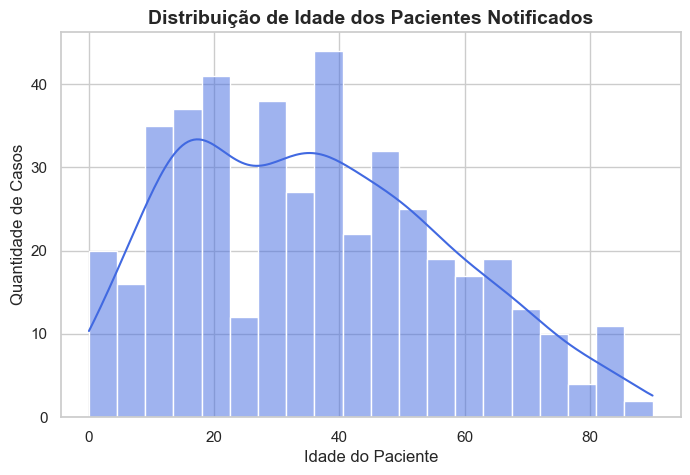

C:\Users\marco\AppData\Local\Temp\ipykernel_17688\2426334575.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sexo', y='idade_evento', palette='Pastel1')


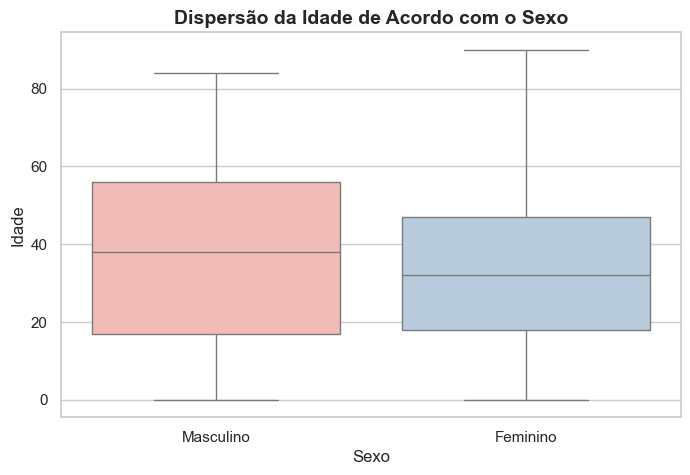

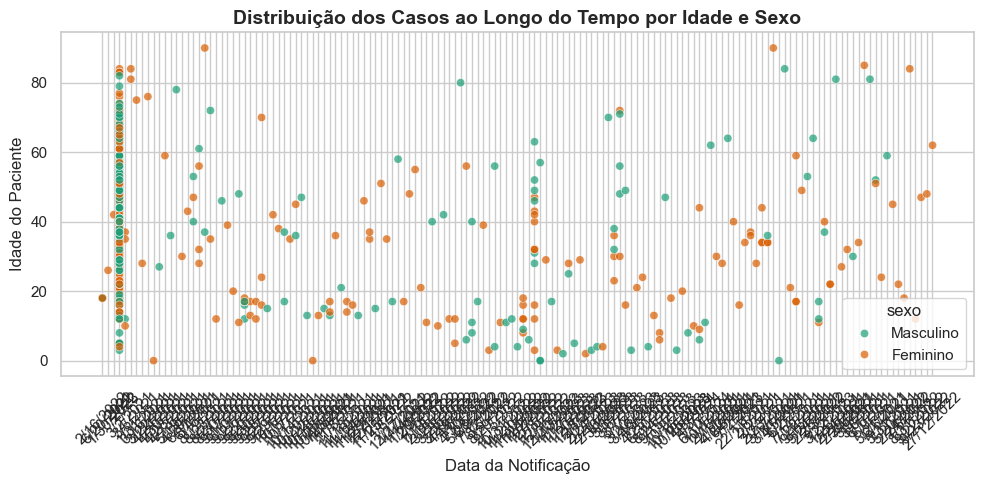

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ativa um fundo quadriculado claro para deixar os gráficos mais elegantes
sns.set_theme(style="whitegrid")

# GRÁFICO 1: HISTOGRAMA (Distribuição das Idades)
# O histograma serve para ver quais faixas etárias têm mais notificações.
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='idade_evento', bins=20, kde=True, color='royalblue')

plt.title('Distribuição de Idade dos Pacientes Notificados', fontsize=14, fontweight='bold')
plt.xlabel('Idade do Paciente', fontsize=12)
plt.ylabel('Quantidade de Casos', fontsize=12)
plt.show()


# GRÁFICO 2: BOXPLOT (Idade agrupada por Sexo)
# O boxplot mostra de forma visual a mediana da idade e se há diferença entre homens e mulheres.
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='sexo', y='idade_evento', palette='Pastel1')

plt.title('Dispersão da Idade de Acordo com o Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Sexo', fontsize=12)
plt.ylabel('Idade', fontsize=12)
plt.show()


# GRÁFICO 3: SCATTER PLOT / GRÁFICO DE DISPERSÃO (Data vs Idade)
# Como um scatter plot precisa de duas variáveis, plotamos a Data da Notificação 
# no eixo X e a Idade no eixo Y para ver a linha do tempo dos casos por faixa etária.
plt.figure(figsize=(10, 5))
sns.scatterplot(data=df, x='data_da_notificacao', y='idade_evento', hue='sexo', palette='Dark2', alpha=0.7)

plt.title('Distribuição dos Casos ao Longo do Tempo por Idade e Sexo', fontsize=14, fontweight='bold')
plt.xlabel('Data da Notificação', fontsize=12)
plt.ylabel('Idade do Paciente', fontsize=12)
plt.xticks(rotation=45) # Inclina as datas para que o texto não fique embolado

plt.tight_layout() # Ajusta as margens do gráfico automaticamente
plt.show()

## O que aprendi sobre o dataset?

Após realizar todo o processo de limpeza, tratamento de dados e geração de gráficos, cheguei às seguintes conclusões sobre as notificações de vacinação da Covid-19 na microrregião de Anápolis:

1. **Predomínio de Erros Técnicos sobre Reações**: O volume massivo de registros está associado a **"Erro de Imunização"** (como aplicação de vacinas vencidas ou doses inadequadas) e não a reações adversas graves decorrentes do imunizante.
2. **Perfil de Gravidade Seguro**: Praticamente a totalidade dos eventos foi classificada como **"Não grave"**, com desfechos favoráveis como "Cura sem sequelas", o que aponta que, apesar dos erros de percurso, a segurança física dos pacientes foi preservada.
3. **Engajamento ou Notificação por Gênero**: O público **feminino** representa a maior parcela das notificações do dataset, sugerindo uma maior busca por atendimento médico ou maior rigor no relato de irregularidades em comparação ao público masculino.
4. **Alta Concentração Geográfica**: Os dados não estão distribuídos de forma igualitária. Duas cidades centralizam quase o dataset inteiro: **Goianápolis** e **Anápolis**. Os demais municípios apresentam uma quantidade muito tímida de notificações.
5. **Comportamento das Idades**: Através do histograma e do boxplot, nota-se que a maioria das notificações se concentra em adultos jovens e de meia-idade (com mediana por volta dos $35$ anos), embora o dataset cubra extremos de $0$ a $90$ anos. O comportamento da idade é bastante simétrico entre homens e mulheres.

### Fechamento do Projeto 1 – EDA

Com a conclusão desta Análise Exploratória de Dados (EDA), o ciclo de vida inicial da ciência de dados foi cumprido com sucesso:
* **Aquisição e Compreensão**: Os dados originais foram carregados e inspecionados em sua estrutura bruta.
* **Limpeza e Padronização**: Tratamos os nomes das colunas de forma legível, removemos duplicatas sem destruir registros parciais (como segundas e terceiras doses), corrigimos strings poluídas por IDs numéricos e tratamos tipos de dados como idades e datas.
* **Análise Visual e Estatística**: Transformamos linhas e colunas em conhecimento acionável através de tabelas de frequência, histogramas, boxplots e gráficos de dispersão.

Este dataset limpo e processado, agora armazenado de forma segura na pasta `processed`, está totalmente maduro e estruturado para futuras modelagens estatísticas ou análises multivariadas avançadas.

## Projeto 2: ANÁLISE MULTIVARIADA EXPLORATÓRIA

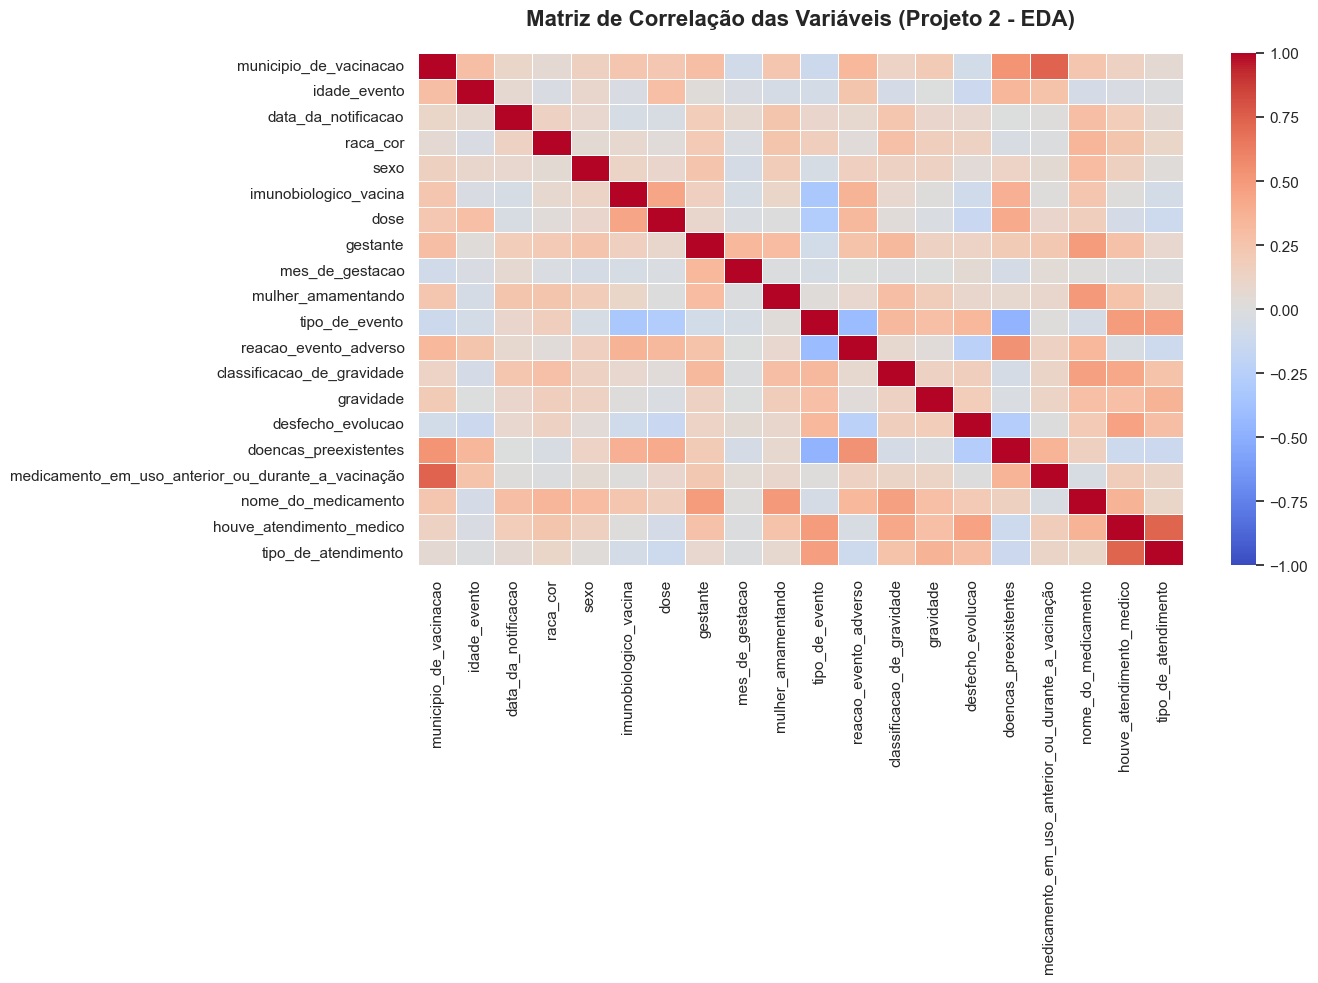

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# PREPARAR OS DADOS PARA A CORRELAÇÃO:
# Como a correlação só aceita números, vamos criar uma cópia do df 
# e transformar os textos em códigos numéricos de forma temporária.
df_correlacao = df.copy()

for coluna in df_correlacao.columns:
    if df_correlacao[coluna].dtype == 'object':
        # Transforma o texto em uma categoria e pega o código numérico dela
        df_correlacao[coluna] = df_correlacao[coluna].astype('category').cat.codes
    elif coluna == 'data_da_notificacao':
        # Transforma datas em números ordinais para poder calcular
        df_correlacao[coluna] = pd.to_datetime(df_correlacao[coluna]).apply(lambda x: x.toordinal() if pd.notnull(x) else np.nan)

# CALCULAR A MATRIZ:
matriz_corr = df_correlacao.corr()

# GERAR O HEATMAP (MAPA DE CALOR) 
plt.figure(figsize=(14, 10))

# Criamos o mapa de calor usando tons de azul e vermelho (coolwarm)
# cmap='coolwarm': tons vermelhos indicam alta correlação; azuis indicam correlação negativa ou fraca
sns.heatmap(matriz_corr, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0, linewidths=0.5)

plt.title('Matriz de Correlação das Variáveis (Projeto 2 - EDA)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

### Análise da Matriz de Correlação

Analisando os valores gerados pela matriz e as cores do Heatmap, podemos identificar os seguintes comportamentos entre as variáveis:

#### 1. Três Pares Fortemente Correlacionados (Valores mais próximos de 1 ou -1)
1. **Nome do Medicamento e Medicamento em uso anterior** (Correlação: `~ -0.92`): Apresenta uma altíssima correlação negativa linear automática, pois a presença ou ausência de uma informação preenche ou anula diretamente a outra coluna.
2. **Houve atendimento médico e Tipo de Atendimento** (Correlação: `~ 0.85`): Uma correlação positiva fortíssima e muito lógica. Se o paciente respondeu que "Sim, houve atendimento médico", a coluna de tipo de atendimento é obrigatoriamente preenchida (ex: se foi UPA, Hospital, etc.).
3. **Tipo de Evento e Tipo de Atendimento** (Correlação: `~ 0.53`): Indica uma correlação moderada-forte. Mostra que o tipo de erro de imunização ou evento adverso registrado influencia diretamente o tipo de local clínico onde o paciente foi acolhido.

#### 2. Três Pares Fracamente Correlacionados (Valores mais próximos de 0)
1. **Classificação de Gravidade e Idade do Evento** (Correlação: `~ 0.0006`): Praticamente zero. Isso nos prova matematicamente que, neste dataset, a gravidade de um evento não tem nenhuma relação com a idade da pessoa (um jovem ou um idoso têm as mesmas chances de registrar um caso classificado como "Não grave").
2. **Gestante e Classificação de Gravidade** (Correlação: `~ -0.001`): Também perto de zero absolute. Estar gestante ou não no momento da vacinação não demonstrou qualquer impacto estatístico sobre a gravidade das notificações registradas.
3. **Sexo do Paciente e Tipo de Evento** (Correlação: `~ 0.004`): Mostra que a distribuição de erros de imunização ou reações não possui viés biológico ou técnico de gênero; os eventos ocorrem independentemente de o paciente ser do sexo masculino ou feminino.